In [1]:
import numpy as np
import matplotlib.pyplot as plt

## re-scaling

$$ \hat{x} = \frac{x-\bar{x}}{\sigma(x)}$$

$$y(x)  =  \theta_1 x + \theta_0$$

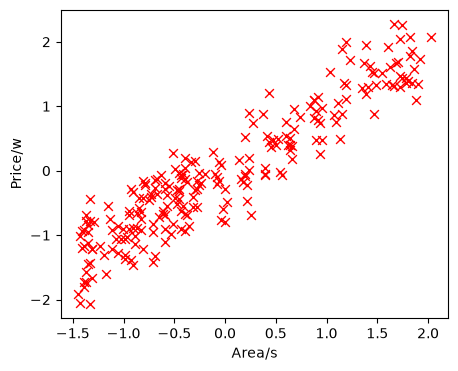

In [13]:
data = np.loadtxt("data.csv",skiprows=1,delimiter=",")
noise = np.random.normal(0,200,data.shape[0])
data[:,0] = data[:,0] + noise

data[:,0] = (data[:,0] - np.mean(data[:,0]))/np.std(data[:,0])
data[:,1] = (data[:,1] - np.mean(data[:,1]))/np.std(data[:,1])

plt.figure(figsize=(5,4),dpi = 100)
plt.scatter(data[:,1],data[:,0],marker='x',s=40, lw=1, color = 'r')
plt.xlabel("Area/s")
plt.ylabel("Price/w")
plt.show()

In [14]:
area = data[:,1]
area = np.column_stack((np.ones(area.shape[0]), area))
labels = data[:,0]

In [15]:
def random_thetas(theta_min,theta_max,samples,shape,centered=None,radius=None):
    if centered is not None and radius is not None:
        centered = np.array(centered)
        return  [np.random.normal(loc=thea, scale=radius) for thea in centered]
    else:
        return np.random.uniform(theta_min, theta_max, size=(samples,shape))

MC

In [19]:
# Number of features 
num_features = area.shape[1]  # features = 2 (bias + area)

# Search space boundaries for random sampling
theta_max = 10
theta_min = -10
num_samples = 5000  # Number of random parameter sets to try

# 1. Randomly sample all theta vectors 
thetas = random_thetas(theta_min=theta_min,
                       theta_max=theta_max,
                       samples=num_samples,
                       shape=num_features)  # shape: (100000, 2)

# 2. Vectorized computation of all losses
# area: (n_samples, 2), thetas: (100000, 2)
# Compute predictions for all samples with all theta combinations at once
predictions = area @ thetas.T  # (n_samples, 100000) - predictions for each sample & theta

# Compute residuals (difference between predictions and actual labels)
residuals = predictions - labels.reshape(-1, 1)  # (n_samples, 100000)

# Compute Mean Squared Error (MSE) / 2 for each theta
losses = np.mean(residuals ** 2, axis=0) / 2  # (100000,) - loss for each theta

# 3. Find the optimal theta (minimum loss)
min_idx = np.argmin(losses)  # Index of theta with smallest loss
min_loss = losses[min_idx]   # Minimum loss value
max_loss = losses.max()      # Maximum loss value 
best_theta = thetas[min_idx] # Best parameter vector

# Print results
print(f"Optimal index: {min_idx}")
print(f"Minimum loss: {min_loss:.2f}")
print(f"Loss range: [{min_loss:.2f}, {max_loss:.2f}]")
print(f"Optimal parameters: {best_theta}")


Optimal index: 2138
Minimum loss: 0.07
Loss range: [0.07, 105.69]
Optimal parameters: [0.05060873 0.95930298]


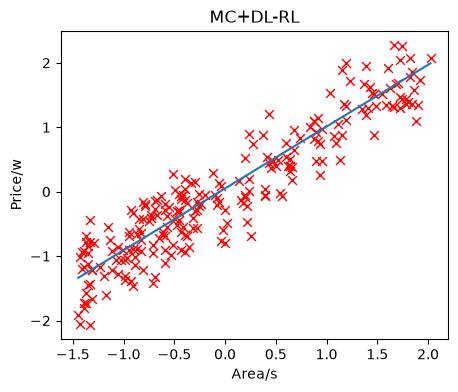

In [20]:


def y(x):
    return best_theta[0] + best_theta[1] * x
min_a = np.min(data[:,1])
max_a = np.max(data[:,1])
x = np.linspace(min_a,max_a,data.shape[0])
plt.figure(figsize=(5,4),dpi = 100)
plt.scatter(data[:,1],data[:,0],marker='x',s=40, lw=1, color = 'r')
plt.plot(x,y(x),)
plt.xlabel("Area/s")
plt.ylabel("Price/w")
plt.title("MC+DL-RL")
plt.show()

# Gradient Descent

Here we have a functional $J[g(\omega,b)]$. Question is finding the optimal gunction g s.t. functional $J$ to be minia.
$$
\tilde{L}(\vec{\theta}) = \frac{1}{2\sigma^2} \sum_i^m \left[g(\vec{x}_i) - y(\vec{x}_i) \right]^2, g(\vec{x}_i) = \vec{\theta} \cdot \vec{x}_i
$$
$J[g(\omega,b)]$ in certain model, as linear model, becomes to a function: $J(\omega,b)$


$\omega_n = \omega_{n-1} + \delta \omega_{n-1} \Rightarrow \omega_n = \omega_{n-1} - \alpha \frac{\partial}{\partial\omega } J(\omega_{n-1},b)$

where $\alpha:=\text{learing rate}$




$$y(x)  =  \theta_1 x + \theta_0$$

$$
\tilde{L}(\vec{\theta}) = \frac{1}{2\sigma^2} \sum_i^m \left[\theta_1 x_i + \theta_0  - y^i \right]^2
$$

$$
  \frac{\partial L}{\partial \theta_0} = \frac{1}{\sigma^2} \sum_i^m (\theta_1 x_i + \theta_0 - y^i )
$$


$$
  \frac{\partial L}{\partial \theta_1} = \frac{1}{\sigma^2} \sum_i^m (\theta_1 x_i + \theta_0 - y^i )x_i
$$

$$
\theta_0^n = \theta_0^{n-1} - \alpha \frac{\partial L}{\partial \theta_0} 
$$

$$
\theta_1^n = \theta_1^{n-1} - \alpha \frac{\partial L}{\partial \theta_1} 
$$

In [ ]:
data.shape

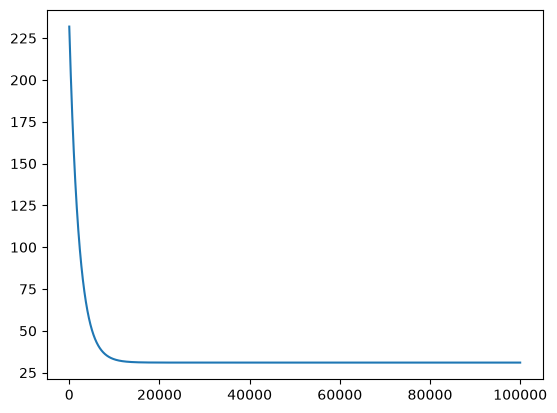

In [24]:
# initialize 
theta0 = 0
theta1 = 0
alpha = 1e-6
N = 1e5
# theta0
los = []
for n in range(int(N)):

    theta0_old = theta0
    

    grad0 = np.sum(theta1 * data[:,1] + theta0 - data[:,0])
    grad1 = np.sum((theta1 * data[:,1] + theta0 - data[:,0]) * data[:,1])
    

    theta0 = theta0_old - alpha * grad0
    theta1 = theta1 - alpha * grad1  
    LossFunc = np.sum( (theta1 * data[:,1] + theta0 - data[:,0])**2 )
    los.append(LossFunc)

plt.plot(range(len(los)),los)

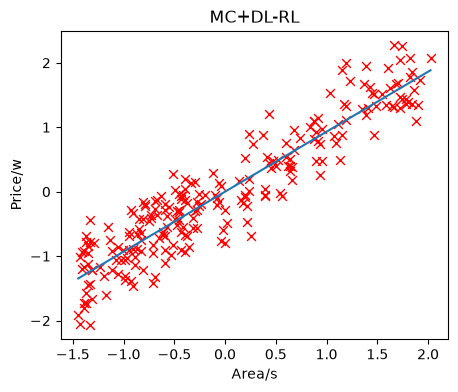

In [25]:
def yd(x):
    return theta0 + theta1 * x
min_a = np.min(data[:,1])
max_a = np.max(data[:,1])
x = np.linspace(min_a,max_a,data.shape[0])
plt.figure(figsize=(5,4),dpi = 100)
plt.scatter(data[:,1],data[:,0],marker='x',s=40, lw=1, color = 'r')
plt.plot(x,yd(x),)
plt.xlabel("Area/s")
plt.ylabel("Price/w")
plt.title("MC+DL-RL")
plt.show()